In [1]:
import pandas as pd

In [7]:
df_users = pd.read_excel(r"D:\Data Analyst Project\PhonePE_analysis\Data\Phonepe-Final-Dataset.xlsx", sheet_name="All_Users")
df_txns = pd.read_excel(r"D:\Data Analyst Project\PhonePE_analysis\Data\Phonepe-Final-Dataset.xlsx", sheet_name="All_Transactions")

In [37]:
df_users.head()

,User_ID,Name,Age,Join_Date,Age_Segments,Age_Segment
0,PP0000001,Holly Rivera,56,2025-06-17,Gen X,Gen X
1,PP0000002,Kevin Lopez,46,2023-12-10,Gen X,Gen X
2,PP0000003,Douglas Roberts,32,2024-09-14,Millenials,Millenials
3,PP0000004,Walter Davila,60,2023-10-19,Boomers,Boomers
4,PP0000005,Grace Blake,25,2025-03-10,Gen Z,Gen Z


In [9]:
df_txns.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07


In [15]:
df_txns.shape

(300000, 8)

In [16]:
df_users.shape

(107658, 4)

# Date Features

In [26]:
df_txns['Date']= pd.to_datetime(df_txns['Date'])
df_txns['Month'] = df_txns['Date'].dt.month
df_txns['DayType'] = df_txns['Date'].dt.dayofweek.apply( lambda x:
                                                            'Weekend' if x >=5 else 'Weekday')

In [38]:
df_txns.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Month,DayType
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,6,Weekend
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,8,Weekend
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,2,Weekday
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,12,Weekend
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,9,Weekend


# Age Segmentation

In [40]:
df_users['Age_Segment'] = pd.cut(df_users['Age'],bins = [0,26,42,58,100], labels = ['Gen Z','Millenials','Gen X','Boomers'])

In [41]:
df_users.head()

,User_ID,Name,Age,Join_Date,Age_Segments,Age_Segment
0,PP0000001,Holly Rivera,56,2025-06-17,Gen X,Gen X
1,PP0000002,Kevin Lopez,46,2023-12-10,Gen X,Gen X
2,PP0000003,Douglas Roberts,32,2024-09-14,Millenials,Millenials
3,PP0000004,Walter Davila,60,2023-10-19,Boomers,Boomers
4,PP0000005,Grace Blake,25,2025-03-10,Gen Z,Gen Z


In [42]:
df = df_txns.merge(df_users[['User_ID','Name','Age','Age_Segment']], on = 'User_ID', how = 'left')

In [43]:
df.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Month,DayType,Name,Age,Age_Segment
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,6,Weekend,Katherine Howard,50,Gen X
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,8,Weekend,Kimberly Mueller,34,Millenials
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,2,Weekday,Scott Davis,36,Millenials
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,12,Weekend,Gina Williams,25,Gen Z
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,9,Weekend,Timothy Hernandez,58,Gen X


In [44]:
df['Payment_Status'].unique()

array(['Successful', 'Failed', 'Wrong PIN', 'Insufficient amount',
       'Server error'], dtype=object)

In [83]:
failed_txns_counts = df[df['Payment_Status'] != 'Successful']

In [84]:
Failed_txns_values = failed_txns_counts['Amount'].sum()

In [85]:
Failed_txns_Services = failed_txns_counts.groupby(['Service'])['Transaction_ID'].count()

In [86]:
Failed_txns_Services

Service
Insurance         2124
Loans             2027
Money_Transfer    5935
Recharge_Bills    1921
Name: Transaction_ID, dtype: int64

In [87]:
failed_txns_amount = failed_txns_counts.groupby(['Service'])['Amount'].sum()

In [88]:
failed_txns_amount

Service
Insurance         2.220716e+07
Loans             1.019782e+08
Money_Transfer    1.512408e+07
Recharge_Bills    1.986356e+06
Name: Amount, dtype: float64

In [89]:
df['Service'].unique()

array(['Recharge_Bills', 'Money_Transfer', 'Loans', 'Insurance'],
      dtype=object)

In [90]:
df[df['Service'] == 'Loans']['Payment_Status'].value_counts()

Payment_Status
Successful             47973
Wrong PIN                700
Server error             692
Insufficient amount      635
Name: count, dtype: int64

In [91]:
from scipy import stats

weekday = df[df['DayType'] == 'Weekday']['Amount']
weekend = df[df['DayType'] == 'Weekend']['Amount']

stat, p = stats.mannwhitneyu(weekday, weekend)
print(f"p-value: {p}")
print("Significant" if p < 0.05 else "Not significant")

p-value: 0.5419910647417419
Not significant


**Result:** p-value = 0.54  
**Conclusion:** No statistically significant difference in transaction amounts between 
weekdays and weekends (p > 0.05). Visual differences in the dashboard reflect 
volume differences only, not behavioral differences in spend amount.

**Business Implication:** Weekend-specific pricing or promotions are not justified 
by transaction value data.

In [92]:
df['Reason'].value_counts()

Reason
Successful             287993
Server error             4053
Wrong PIN                3315
Insufficient amount      3304
Wrong Info                700
Bank Denied               635
Name: count, dtype: int64

In [94]:
failed_txns_counts.groupby(['Service', 'Reason'])['Transaction_ID'].count().unstack().fillna(0)

Reason,Bank Denied,Insufficient amount,Server error,Wrong Info,Wrong PIN
Service,,,,,
Insurance,0.0,692.0,715.0,0.0,717.0
Loans,635.0,0.0,692.0,700.0,0.0
Money_Transfer,0.0,1994.0,1985.0,0.0,1956.0
Recharge_Bills,0.0,618.0,661.0,0.0,642.0


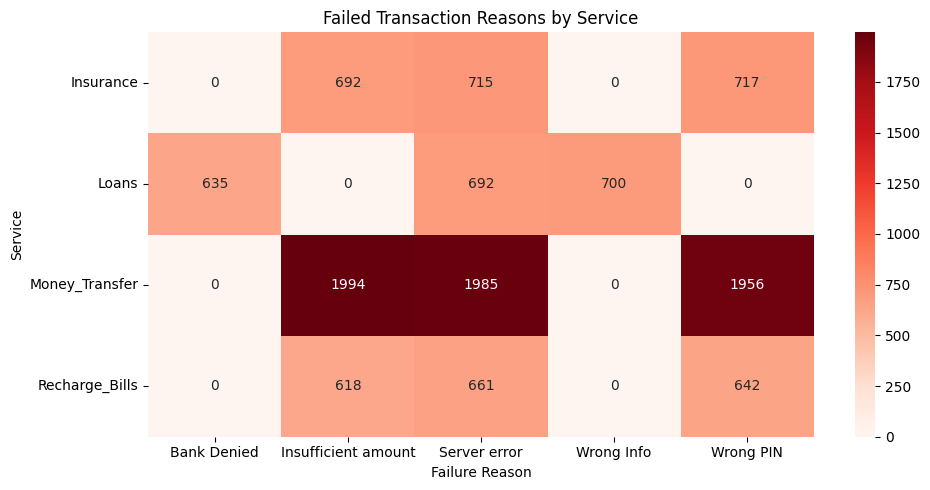

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

reason_pivot = failed_txns_counts.groupby(['Service', 'Reason'])['Transaction_ID'].count().unstack().fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(reason_pivot, annot=True, fmt='.0f', cmap='Reds')
plt.title('Failed Transaction Reasons by Service')
plt.ylabel('Service')
plt.xlabel('Failure Reason')
plt.tight_layout()
plt.show()

## Failure Reason Analysis by Service

Breakdown of why transactions fail across each service category.

**Key Findings:**
- Money Transfer has the highest absolute failures across all reason types
- Insurance and Recharge Bills failures are evenly split across Wrong PIN, 
  Server Error and Insufficient Amount
- Loans uniquely shows Bank Denied and Wrong Info failures — 
  suggesting third-party bank rejection issues specific to loan disbursements
- No single failure reason dominates — points to systemic issues 
  across multiple failure points

**Business Implication:** Loans require bank-level integration fixes. 
Money Transfer needs across-the-board reliability improvements.

In [97]:
from datetime import datetime

snapshot_date = df['Date'].max()

rfm = df[df['Payment_Status'] == 'Successful'].groupby('User_ID').agg(
    Recency  = ('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency= ('Transaction_ID', 'count'),
    Monetary = ('Amount', 'sum')
).reset_index()

# Score each into 3 tiers
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=3, labels=[3, 2, 1])  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=3, labels=[1, 2, 3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=3, labels=[1, 2, 3])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

rfm['Segment'] = pd.cut(rfm['RFM_Score'], bins=[2, 5, 7, 9],
                          labels=['Low Value', 'Mid Value', 'High Value'])

print(rfm['Segment'].value_counts())

Segment
Low Value     45644
Mid Value     30802
High Value    23574
Name: count, dtype: int64


C:\Users\pande\AppData\Local\Temp\ipykernel_21856\86935703.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rfm['Segment'].value_counts().index,


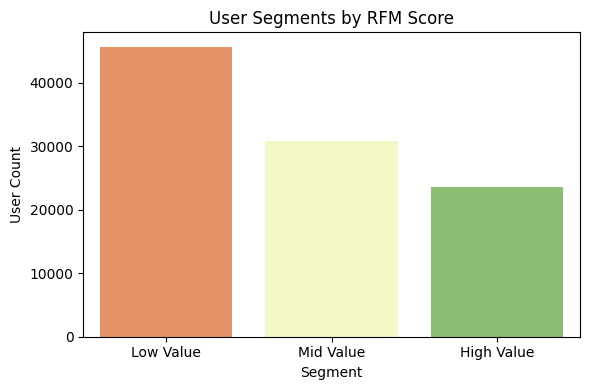

In [98]:
plt.figure(figsize=(6, 4))
sns.barplot(x=rfm['Segment'].value_counts().index, 
            y=rfm['Segment'].value_counts().values, 
            palette='RdYlGn')
plt.title('User Segments by RFM Score')
plt.xlabel('Segment')
plt.ylabel('User Count')
plt.tight_layout()
plt.show()

## RFM Segmentation

Users segmented into 3 tiers based on Recency, Frequency, and Monetary value 
of successful transactions only.

| Segment    | Users  |
|------------|--------|
| High Value | 23,574 |
| Mid Value  | 30,802 |
| Low Value  | 45,644 |

**Note:** Analysis based on 2024 transaction data. Scores are relative — 
users ranked against each other within the dataset.

**Business Implication:** 23.5K High Value users driving disproportionate 
revenue — priority targets for retention campaigns. 45K Low Value users 
represent re-engagement opportunity.

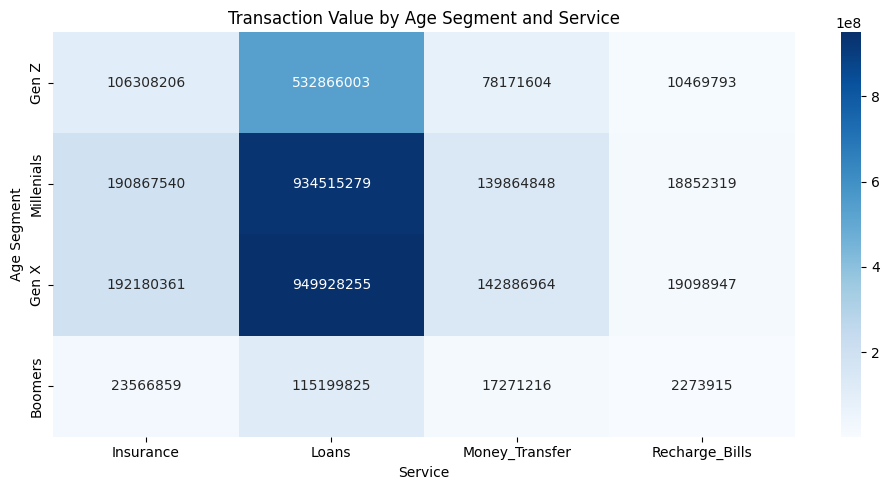

In [99]:
age_service = pd.crosstab(df['Age_Segment'], df['Service'], 
                           values=df['Amount'], aggfunc='sum')

plt.figure(figsize=(10, 5))
sns.heatmap(age_service, annot=True, fmt='.0f', cmap='Blues')
plt.title('Transaction Value by Age Segment and Service')
plt.ylabel('Age Segment')
plt.xlabel('Service')
plt.tight_layout()
plt.show()

## Age Segment × Service Heatmap

Transaction value (₹) breakdown across generations and service categories.

**Key Findings:**
- Loans dominates across all age segments — Gen X (₹94.9Cr) and 
  Millennials (₹93.4Cr) are the heaviest borrowers
- Gen Z shows surprisingly high Loan usage (₹53.2Cr) — indicates 
  early credit adoption among younger users
- Recharge & Bills is the lowest value service across all segments — 
  high frequency but low ticket size
- Boomers have the lowest activity overall — expected given lower 
  digital payment adoption
- Insurance is consistently the second highest across all segments

**Business Implication:** Loan products should be the primary focus for 
retention and upsell campaigns across all age groups. Gen Z loan volume 
signals an opportunity for targeted youth credit products.